### Setup

In [9]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import pandas as pd
from pathlib import Path


In [6]:
def quick_plot(func,x = None,y = None,yerr = None,label = None , title = None , x_title = None , 
               y_title = None, p0 = None,log = '.'):
    """
    Uses Scipy curve_fit to automatically create comparison plot and residual plot.
    MUST define func() before using function!
    Can take inf amount of function arguments!
    Stores Scipy Perr and popt
    """

    popt, pcov = curve_fit(func,x,y,sigma = yerr, absolute_sigma = True, p0=p0)

    perr = np.sqrt(np.diag(pcov))
    
    y_fit = func(x,*popt)
    
    print(*popt)
    print(*perr)

    plt.errorbar (x, y,fmt = 'o',yerr = yerr,label = label )
    plt.plot(x,y_fit)
    plt.title(title)
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.grid()
    plt.show()


    resid = y - y_fit

    plt.errorbar(x,resid,yerr = yerr, fmt = 'o',label = label)
    plt.axhline(y = 0, color = 'black', linestyle = '--')
    plt.grid()
    plt.legend()
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(title)
    plt.show()


### Test 1: Messing Around

In [7]:
df_r = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Speclab/data/PHYS 133_Atomic Spectra Lab_Data - Hg_R.csv')
df_l = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Speclab/data/PHYS 133_Atomic Spectra Lab_Data - Hg_L.csv')
df_o = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Speclab/data/PHYS 133_Atomic Spectra Lab_Data - Hg_M.csv')
#right dial 
theta_A_0 = df_o.iloc[:,1]
theta_B_0 = df_o.iloc[:,2]

theta_L_A = df_l.iloc[:2,1]
theta_L_B = df_l.iloc[:2,2]

theta_R_A = df_r.iloc[:2,1]
theta_R_B = df_r.iloc[:2,2]

#left dial
theta = 0.25 * (theta_L_A + theta_L_B + theta_R_A + theta_R_B - 2*(theta_A_0 + theta_B_0))

m = np.array([1,2])

sigma = np.sqrt(np.square(df_o.iloc[:2,3])+ 
                np.square(df_o.iloc[:2,4])+ 
                np.square(df_r.iloc[:2,3])+
                np.square(df_r.iloc[:2,4])+
                np.square(df_l.iloc[:2,3])+
                np.square(df_l.iloc[:2,4]))


wave = 546.074 *1e-9
x = m * wave
y = np.nan_to_num(np.sin(theta))

def func(x,d):
    return (x)/d

quick_plot(func, x,y,yerr = sigma )



FileNotFoundError: [Errno 2] No such file or directory: '/Users/cadenjensen/Desktop/Phys 133/Speclab/data/PHYS 133_Atomic Spectra Lab_Data - Hg_R.csv'

3.5206190978584327e-06
7.458658146248766e-07


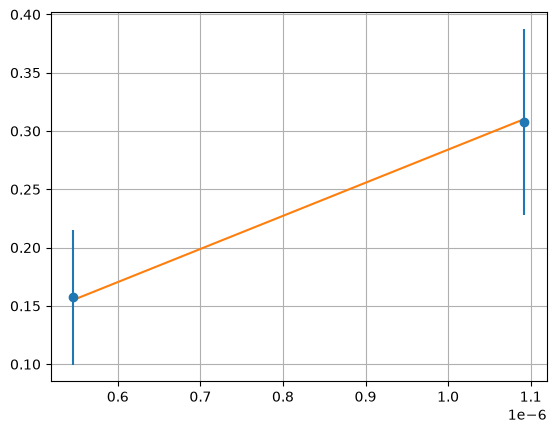

/var/folders/_c/5y50sbcs15x51qmpgmm2ftk00000gn/T/ipykernel_45145/380527742.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


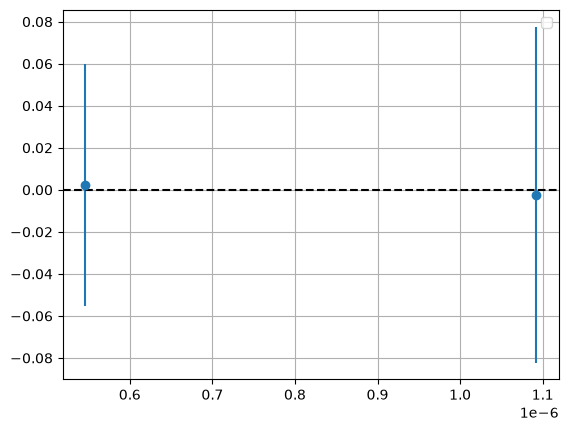

In [ ]:
# 1. Consistently slice ALL data to the first 2 rows [:2] to avoid NaN mismatches
theta_A_0 = df_o.iloc[0, 1]
theta_B_0 = df_o.iloc[0, 2]
theta_L_A = df_l.iloc[:2, 1]
theta_L_B = df_l.iloc[:2, 2]
theta_R_A = df_r.iloc[:2, 1]
theta_R_B = df_r.iloc[:2, 2]

# 2. Calculate separate left and right deviations to prevent cancellation
dev_L = 0.5 * ((theta_L_A - theta_A_0) + (theta_L_B - theta_B_0))
dev_R = 0.5 * ((theta_A_0 - theta_R_A) + (theta_B_0 - theta_R_B))

# Average deviation angle (in degrees)
theta_deg = 0.5 * (np.abs(dev_L) + np.abs(dev_R))

# 3. Convert degrees to radians before taking the sine
y = np.nan_to_num(np.sin(np.radians(theta_deg)))

m = np.array([1, 2])
sigma = np.sqrt(np.square(df_o.iloc[0, 3]) + np.square(df_o.iloc[0, 4]) + 
                np.square(df_r.iloc[:2, 3]) + np.square(df_r.iloc[:2, 4]) + 
                np.square(df_l.iloc[:2, 3]) + np.square(df_l.iloc[:2, 4]))

# Convert degrees error in sigma to radians if your raw error column is in degrees

wave = 546.074 * 1e-9
x = m * wave

def func(x, d): 
    return x / d

sigma_rad = np.radians(sigma)


quick_plot(func, x, y, yerr=sigma)


### Mercury Tube, spacing check

Fitted Line Spacing (m): 289.13± 0.21
Fitted Line Spacing Percent Error (%): 3.62± 0.07


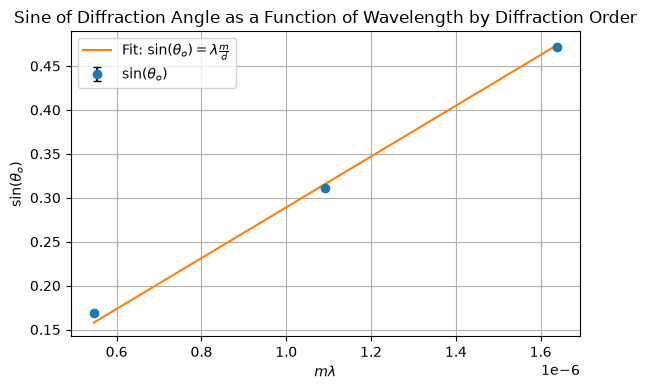

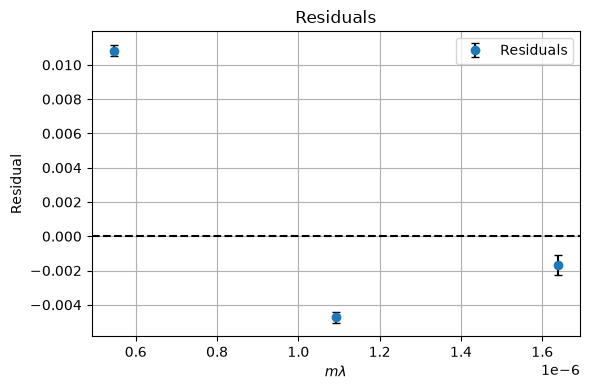

χ² = 1467.32
 χ² = 1467.32
p-value = 0.0
0     9.713889
1    18.122222
2    28.163889
Name: alpha, dtype: float64


In [37]:



df = pd.read_csv(r'/home/cadenj/Desktop/Phys-133/Speclab/data_new_Hg/mainmerc.csv')
df0 = pd.read_csv(r'/home/cadenj/Desktop/Phys-133/Speclab/data_new_Hg/mainzeromerc.csv')


m = df.iloc[:,0]
wave = 546.074 * 1e-9
x = wave * m
y = np.sin(np.radians(df.iloc[:,1]))


sigma = np.cos(np.radians(df.iloc[:,1])) *np.radians(df.iloc[:,2]) 


def func(x,d):
     return (x/d) 

popt, pcov = curve_fit(func, x, y, sigma=sigma, absolute_sigma=True, p0=[1.6e-6])
perr = np.sqrt(np.diag(pcov))

d = popt[0]
d_true = 300 #lines per mm

space = 1/(d*1e3)
spacerr = perr[0]/(d**2 * 1e3)

print("Fitted Line Spacing (m):",f"{space:.2f}" "±", f"{spacerr:.2f}")

percent = (np.abs(space - d_true)/d_true)*100
percenterr = (spacerr/d_true)*100


print("Fitted Line Spacing Percent Error (%):",f"{percent:.2f}" "±", f"{percenterr:.2f}")

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(x, y, yerr=sigma, capsize=3, ecolor='black',
            fmt='o', label=r'$\sin(\theta_o)$')
ax.plot(x, y_fit, '-', label=r"Fit: $\sin(\theta_o)=\lambda\frac{m}{d}$")

ax.set_xlabel(r"$m\lambda$")
ax.set_ylabel(r"$\sin(\theta_o)$")
ax.set_title("Sine of Diffraction Angle as a Function of Wavelength by Diffraction Order")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()


resid = y - y_fit
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(x, resid, yerr=sigma, capsize=3, ecolor='black',
            fmt='o', label="Residuals")
ax.axhline(0, color='black', linestyle='--')

ax.set_xlabel(r"$m\lambda$")
ax.set_ylabel("Residual")
ax.set_title("Residuals")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()


chi2 = np.sum((resid / sigma) ** 2)
dof = len(x) - len(popt)
chi2 = chi2 

print(f"χ² = {chi2:.2f}")
print(f" χ² = {chi2:.2f}")

p_val = stats.chi2.sf(chi2, dof)
print(f"p-value = {p_val}")

print(df.iloc[:,1])




### Hydrogen Rydburg Constant

some left and right vernier readings were off by a degree or two which caused our systematic error to be larger than out estimated uncertainty. 

In other words, our propagated uncertainties only include measurement percision whilst our experiment is clearly dominated by systemiatic error.

Wavelength; m=1: Wave = 710.81
Wavelength; m=2: Wave = 715.38
Wavelength; m=3: Wave = 690.04
Rydburg Constant; m=1: R = 1.0129e+07 ± 2.5342e+04 1/m 
Rydburg Constant; m=2: R = 1.0065e+07 ± 1.4953e+04 1/m 
Rydburg Constant; m=3: R = 1.0434e+07 ± 7.8549e+03 1/m 
Rydburg Constant Percent Error; m=1: R = 7.64 ± 0.23 % 
Rydburg Constant Percent Error; m=2: R = 8.23 ± 0.14 % 
Rydburg Constant Percent Error; m=3: R = 4.87 ± 0.07 % 
Rydburg Constant ~ Average; m=3: R = 1.0209e+07 ± 1.0152e+04 1/m 
Rydburg Constant Percent Error ~ Average; m=3: R = 6.92 ± 0.09 % 


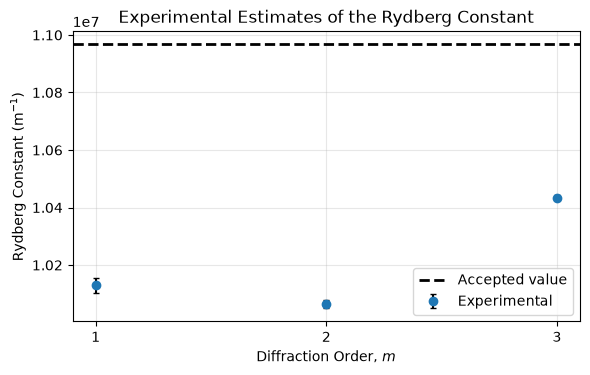

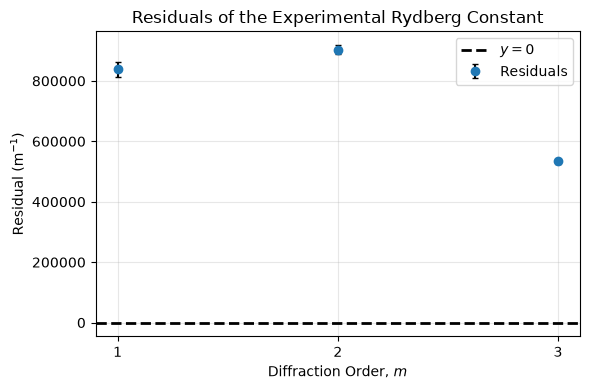

χ² = 9358.12
   m  left_ver   right_ver  vibed_uncert_1  vibed_uncer_2
0  1    168.00  348.333333        0.066667       0.050000
1  2    155.25  334.050000        0.100000       0.100000
2  3    139.00  319.333333        0.066667       0.083333
   m    left_ver  right_ver  vibed_uncert_1  vibed_uncer_2
0  1  193.466667  12.166667        0.033333       0.050000
1  2  206.016667  25.066667        0.000000       0.033333
2  3  217.033333  35.050000        0.033333       0.033333
m                   3.000000
left_ver          139.000000
right_ver         319.333333
vibed_uncert_1      0.066667
vibed_uncer_2       0.083333
Name: 2, dtype: float64
m                   3.000000
left_ver          217.033333
right_ver          35.050000
vibed_uncert_1      0.033333
vibed_uncer_2       0.033333
Name: 2, dtype: float64


In [ ]:

root_path = Path.home()

spec_lab = next(root_path.rglob("*Speclab*"))


df_l = pd.read_csv(spec_lab / 'data_H/PHYS_133_Atomic_Spectra_Lab_Data - H_L (1).csv')
df_m = pd.read_csv(spec_lab / 'data_H/PHYS_133_Atomic_Spectra_Lab_Data - H_M (1).csv')
df_r = pd.read_csv(spec_lab / 'data_H/PHYS_133_Atomic_Spectra_Lab_Data - H_R (1).csv')

#Middle Average Balmer Series 
df_m_avg_2 = (df_m.iloc[:,1]-180 + df_m.iloc[:,2])/2
df_m_avg_sig_2 = np.sqrt((df_m.iloc[:,3])**2 + (df_m.iloc[:,4])**2)/2

N = len(df_m_avg_2)
df_m_avg = np.mean(df_m_avg_2)
df_m_avg_sig = np.sqrt(np.sum(df_m_avg_sig_2**2))/N

#Average Left Balmer Series
df_l_avg = (180 - df_l.iloc[:,1] - df_m_avg+ 360 - df_l.iloc[:,2] - df_m_avg)/2
df_l_avg_sig = np.sqrt((df_l.iloc[:,3])**2 + (df_l.iloc[:,4])**2)/2
df_l_avg_sig = np.sqrt((df_l_avg_sig)**2 + (df_m_avg_sig)**2)

#Average Right Balmer Series
df_r_avg = (df_r.iloc[:,1]-180 + df_m_avg + df_r.iloc[:,2] + df_m_avg)/2
df_r_avg_sig = np.sqrt((df_r.iloc[:,3])**2 + (df_r.iloc[:,4])**2)/2
df_r_avg_sig = np.sqrt((df_r_avg_sig)**2 + df_m_avg_sig**2)

m = df_r.iloc[:,0]
d = 3.33e-6 #(m)

theta = (df_l_avg + df_r_avg)/2
theta_sig = np.sqrt(df_l_avg_sig**2 + df_r_avg_sig**2)/2

theta_rad = np.radians(theta)
theta_sig_rad = np.radians(theta_sig)

lam = d*np.sin(theta_rad)/m

lam_sig = (d*np.abs(np.cos(theta_rad))/m)*theta_sig_rad

x = m



R = 36/(5*lam) # n = 3 to n = 2 transition for Balmer Series
R_sig = (R*lam_sig/lam) 
R_true = 10967758



percent_diff = (np.abs(R-R_true)/R_true)*100
percent_diff_err = (R_sig/R_true)*100

for i in range(len(R)):
    print(f"Wavelength; m={i+1}: Wave = {lam[i]*1e9:.2f}")

for i in range(len(R)):
    print(f"Rydburg Constant; m={i+1}: R = {R[i]:.4e} ± {R_sig[i]:.4e} 1/m ")
for i in range(len(R)):
    print(f"Rydburg Constant Percent Error; m={i+1}: R = {percent_diff[i]:.2f} ± {percent_diff_err[i]:.2f} % ")

R_avg = np.mean(R)
R_avg_sig = np.sqrt(np.sum(R_sig**2))/len(R_sig)
print(f"Rydburg Constant ~ Average; m={i+1}: R = {R_avg:.4e} ± {R_avg_sig:.4e} 1/m ")

Rp_avg = np.mean(percent_diff)
Rp_avg_sig = np.sqrt(np.sum(percent_diff_err**2))/len(percent_diff_err)
print(f"Rydburg Constant Percent Error ~ Average; m={i+1}: R = {Rp_avg:.2f} ± {Rp_avg_sig:.2f} % ")


fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(m, R, yerr=R_sig,fmt='o',color='tab:blue',markersize=6,capsize=2,ecolor='black',label='Experimental')

ax.axhline(R_true,color='black',linestyle='--',linewidth=2,label='Accepted value')

ax.set_xlabel("Diffraction Order, $m$")
ax.set_ylabel(r"Rydberg Constant ($\mathrm{m^{-1}}$)")
ax.set_title("Experimental Estimates of the Rydberg Constant")
ax.set_xticks([1, 2, 3])
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()


# -----------------------
# Residual Plot
# -----------------------
# Residual Plot

resid = R_true - R

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(m, resid,yerr=R_sig,fmt='o',color='tab:blue',markersize=6,capsize=2,ecolor='black',label='Residuals')

ax.axhline(0,color='black',linestyle='--',linewidth=2,label=r"$y=0$")

ax.set_xlabel("Diffraction Order, $m$")
ax.set_ylabel(r"Residual ($\mathrm{m^{-1}}$)")
ax.set_title("Residuals of the Experimental Rydberg Constant")
ax.set_xticks([1, 2, 3])
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()
chi2 = np.sum((resid / R_sig) ** 2)
dof = len(x) - 1
chi2 = chi2 

print(f"χ² = {chi2:.2f}")


print(df_l)
print(df_r)


print(df_l.iloc[2])
print(df_r.iloc[2])








### Neon

Fitted Wavelength (nm): 636.42 ± 0.61
Fitted Wavelength Percent Error (%): 0.57 ± 0.10


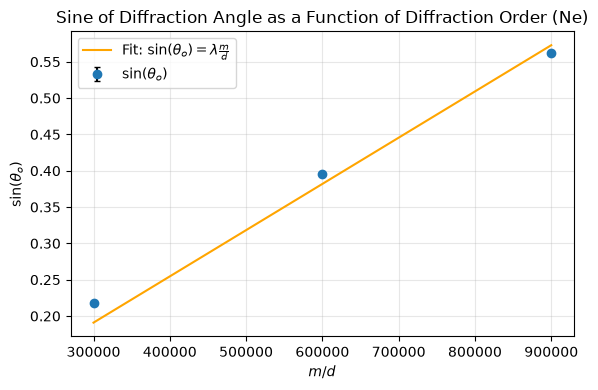

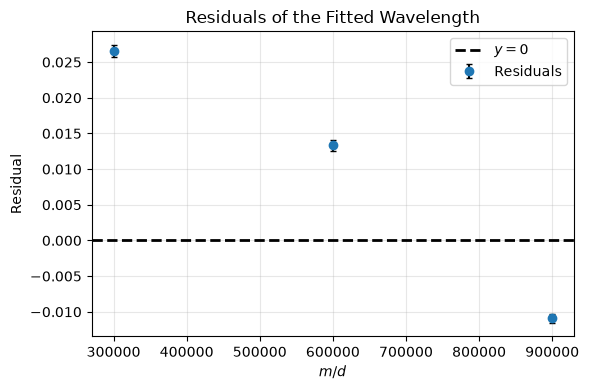

χ² = 1531.98
p-value = 0.0
   m    left_ver   right_ver  vibed_uncert_1  vibed_uncert_2
0  1  168.266667  348.166667        0.083333        0.066667
1  2  156.050000  336.000000        0.050000        0.066667
2  3  145.933333  325.683333        0.050000        0.050000
   m    left_ver  right_ver  vibed_uncert_1  vibed_uncer_2
0  1  195.900000  10.766667        0.100000       0.116667
1  2  203.166667  22.000000        0.150000       0.050000
2  3  214.366667  34.000000        0.083333       0.116667


In [26]:
from pathlib import Path 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats

root_path = Path.home()

spec_lab = next(root_path.rglob("*Speclab*"))

df_ne_l = pd.read_csv(spec_lab / 'data_Ne/PHYS_133_Atomic_Spectra_Lab_Data - Ne_L.csv')
df_ne_m = pd.read_csv(spec_lab / 'data_Ne/PHYS_133_Atomic_Spectra_Lab_Data - Ne_M.csv')
df_ne_r = pd.read_csv(spec_lab / 'data_Ne/PHYS_133_Atomic_Spectra_Lab_Data - Ne_R.csv')

#Middle Average
df_m_avg_2 = (df_ne_m.iloc[:,1]-180 + df_ne_m.iloc[:,2])/2
df_m_avg_sig_2 = np.sqrt((df_ne_m.iloc[:,3])**2 + (df_ne_m.iloc[:,4])**2)/2

N = len(df_m_avg_2)
df_m_avg = np.mean(df_m_avg_2)
df_m_avg_sig = np.sqrt(np.sum(df_m_avg_sig_2**2))/N

#Average Left
df_l_avg = (180 - df_ne_l.iloc[:,1] - df_m_avg + 360 - df_ne_l.iloc[:,2] - df_m_avg)/2
df_l_avg_sig = np.sqrt((df_ne_l.iloc[:,3])**2 + (df_ne_l.iloc[:,4])**2)/2
df_l_avg_sig = np.sqrt((df_l_avg_sig)**2 + (df_m_avg_sig)**2)

#Average Right
df_r_avg = (df_ne_r.iloc[:,1]-180 + df_m_avg + df_ne_r.iloc[:,2] + df_m_avg)/2
df_r_avg_sig = np.sqrt((df_ne_r.iloc[:,3])**2 + (df_ne_r.iloc[:,4])**2)/2
df_r_avg_sig = np.sqrt((df_r_avg_sig)**2 + df_m_avg_sig**2)

m = df_ne_r.iloc[:,0]
d = 1/(300 * 1e3)  # (m) -- grating spacing assumed known: 300 lines/mm

theta = (df_l_avg + df_r_avg)/2
theta_sig = np.sqrt(df_l_avg_sig**2 + df_r_avg_sig**2)/2 

theta_rad = np.radians(theta)
theta_sig_rad = np.radians(theta_sig) 

x = m / d
y = np.sin(theta_rad)
sigma = np.cos(theta_rad) * theta_sig_rad


def func(x, wave):
    return (x*wave)


popt, pcov = curve_fit(func, x, y, sigma=sigma, absolute_sigma=True, p0=[600e-9])
perr = np.sqrt(np.diag(pcov))

wave = popt[0]
wave_true = 632.8e-9  

wave_nm = wave*1e9
wave_err_nm = perr[0]*1e9

print("Fitted Wavelength (nm):", f"{wave_nm:.2f}", "±", f"{wave_err_nm:.2f}")

percent = (np.abs(wave - wave_true)/wave_true)*100
percenterr = (perr[0]/wave_true)*100

print("Fitted Wavelength Percent Error (%):", f"{percent:.2f}", "±", f"{percenterr:.2f}")

y_fit = func(x, *popt)

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    x, y, yerr=sigma,
    fmt='o',
    color='tab:blue',
    markersize=6,
    capsize=2,
    ecolor='black',
    label=r'$\sin(\theta_o)$'
)

ax.plot(x, y_fit, '-', color='orange', label=r"Fit: $\sin(\theta_o)=\lambda\frac{m}{d}$")

ax.set_xlabel(r"$m/d$")
ax.set_ylabel(r"$\sin(\theta_o)$")
ax.set_title("Sine of Diffraction Angle as a Function of Diffraction Order (Ne)")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()


resid = y - y_fit

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    x, resid, yerr=sigma,
    fmt='o',
    color='tab:blue',
    markersize=6,
    capsize=2,
    ecolor='black',
    label='Residuals'
)

ax.axhline(0, color='black', linestyle='--', linewidth=2, label=r"$y=0$")

ax.set_xlabel(r"$m/d$")
ax.set_ylabel("Residual")
ax.set_title("Residuals of the Fitted Wavelength")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

chi2 = np.sum((resid / sigma) ** 2)
dof = len(x) - len(popt)
chi2 = chi2

print(f"χ² = {chi2:.2f}")

p_val = stats.chi2.sf(chi2, dof)
print(f"p-value = {p_val}")

print(df_ne_l)
print(df_ne_r)

### Hg_new

Fitted Line Spacing (m): 290.76± 0.07
Fitted Line Spacing Percent Error (%): 3.08± 0.02
0    0.165478
1    0.165119
2    0.309155
3    0.321233
4    0.470627
5    0.484555
dtype: float64


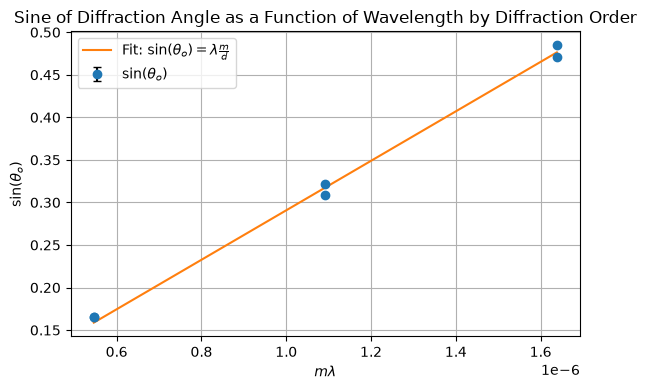

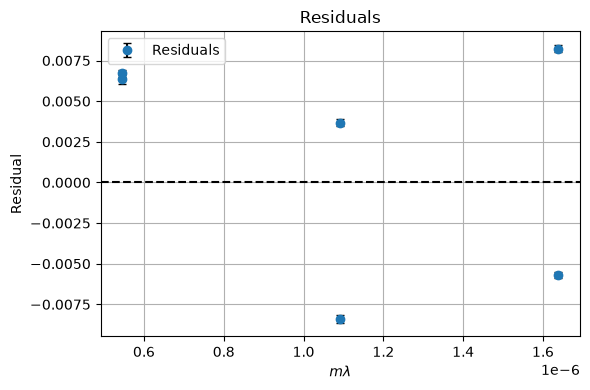

χ² = 5491.87


In [27]:
from pathlib import Path 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats

root_path = Path.home()

spec_lab = next(root_path.rglob("*Speclab*"))

df_hg_l = pd.read_csv(spec_lab / 'data_Hg_complete/PHYS_133_Atomic_Spectra_Lab_Data - Hg_L.csv')
df_hg_m = pd.read_csv(spec_lab / 'data_Hg_complete/PHYS_133_Atomic_Spectra_Lab_Data - Hg_M.csv')
df_hg_r = pd.read_csv(spec_lab / 'data_Hg_complete/PHYS_133_Atomic_Spectra_Lab_Data - Hg_R.csv')

#Middle Average
df_m_avg_2 = (df_hg_m.iloc[:,1]-180 + df_hg_m.iloc[:,2])/2
df_m_avg_sig_2 = np.sqrt((df_hg_m.iloc[:,3])**2 + (df_hg_m.iloc[:,4])**2)/2

N = len(df_m_avg_2)
df_m_avg = np.mean(df_m_avg_2)
df_m_avg_sig = np.sqrt(np.sum(df_m_avg_sig_2**2))/N

#Average Left
df_l_avg = (180 - df_hg_l.iloc[:,1] - df_m_avg + 360 - df_hg_l.iloc[:,2] - df_m_avg)/2
df_l_avg_sig = np.sqrt((df_hg_l.iloc[:,3])**2 + (df_hg_l.iloc[:,4])**2)/2
df_l_avg_sig = np.sqrt((df_l_avg_sig)**2 + (df_m_avg_sig)**2)

#Average Right
df_r_avg = (df_hg_r.iloc[:,1]-180 + df_m_avg + df_hg_r.iloc[:,2] + df_m_avg)/2
df_r_avg_sig = np.sqrt((df_hg_r.iloc[:,3])**2 + (df_hg_r.iloc[:,4])**2)/2
df_r_avg_sig = np.sqrt((df_r_avg_sig)**2 + df_m_avg_sig**2)

m = df_hg_r.iloc[:,0]
wave = 546.074 * 1e-9  # known Hg green line (m)

theta = (df_l_avg + df_r_avg)/2
theta_sig = np.sqrt(df_l_avg_sig**2 + df_r_avg_sig**2)/2

theta_rad = np.radians(theta)
theta_sig_rad = np.radians(theta_sig)

x = wave * m
y = np.sin(theta_rad)
sigma = np.cos(theta_rad) * theta_sig_rad


def func(x,d):
     return (x/d) 

popt, pcov = curve_fit(func, x, y, sigma=sigma, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

d = popt[0]
d_true = 300 #lines per mm

space = 1/(d*1e3)
spacerr = perr[0]/(d**2 * 1e3)

print("Fitted Line Spacing (m):",f"{space:.2f}" "±", f"{spacerr:.2f}")

percent = (np.abs(space - d_true)/d_true)*100
percenterr = (spacerr/d_true)*100


print("Fitted Line Spacing Percent Error (%):",f"{percent:.2f}" "±", f"{percenterr:.2f}")

y_fit = func(x, *popt)

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(x, y, yerr=sigma, capsize=3, ecolor='black',fmt='o', label=r'$\sin(\theta_o)$')
ax.plot(x, y_fit, '-', label=r"Fit: $\sin(\theta_o)=\lambda\frac{m}{d}$")
print(y)

ax.set_xlabel(r"$m\lambda$")
ax.set_ylabel(r"$\sin(\theta_o)$")
ax.set_title("Sine of Diffraction Angle as a Function of Wavelength by Diffraction Order")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()


resid = y - y_fit
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(x, resid, yerr=sigma, capsize=3, ecolor='black',
            fmt='o', label="Residuals")
ax.axhline(0, color='black', linestyle='--')

ax.set_xlabel(r"$m\lambda$")
ax.set_ylabel("Residual")
ax.set_title("Residuals")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()


chi2 = np.sum((resid / sigma) ** 2)
dof = len(x) - len(popt)
chi2 = chi2 

print(f"χ² = {chi2:.2f}")




